In [18]:
import sys
module_path = '../preprocess'
module_path = '/Users/us3519/femaleflystates/preprocess/'
module_path = '/Users/us3519/femaleflystates/'
if module_path not in sys.path:
    sys.path.append(module_path)

In [19]:
sys.path

['/Users/us3519/mambaforge/lib/python310.zip',
 '/Users/us3519/mambaforge/lib/python3.10',
 '/Users/us3519/mambaforge/lib/python3.10/lib-dynload',
 '',
 '/Users/us3519/dynaenv/lib/python3.10/site-packages',
 '../preprocess',
 '/Users/us3519/femaleflystates/preprocess/',
 '/Users/us3519/femaleflystates/']

In [437]:
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [158]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams["font.size"] = 18

In [21]:
from preprocess.leaprig import WT_DATA

In [433]:
figpath = '/Users/us3519/femaleflystates/paper figs/figure_behavior/'

In [37]:
event = 'song'
event_etas = joblib.load(f'../data/wt/ETAs/{event}-eta_traces_unzscored.pkl')
ETAs, ETA_stds, ETA_sems, all_traces = event_etas

In [38]:
DATA = WT_DATA
event_window = DATA.event_window
before_event_window = DATA.before_event_window

In [39]:
all_traces.keys()

dict_keys(['mFV', 'fFV', 'fLS', 'mfDist', 'fTheta_tLeft', 'fTheta_tRight', 'fTheta_sLeft', 'fTheta_sRight'])

In [66]:
feat = 'fTheta_sLeft'
THRESHOLD_SPEED = 0     # mm/s

In [67]:
ridxs = np.random.choice(len(all_traces[feat]), min(len(all_traces[feat]), 100))

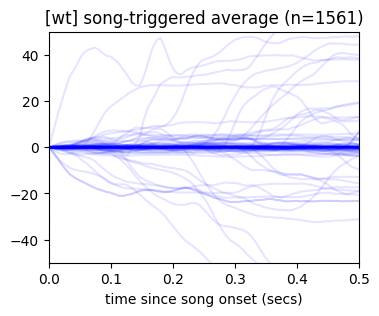

In [68]:
plt.figure(figsize=(4, 3))
plt.plot(event_window/DATA.fps, all_traces[feat][ridxs].T, c='b', alpha=0.1)
# plt.plot(event_window/DATA.fps, ETAs[feat], c='b', label='ETA')
plt.axvline(0, ls=':', c='r')
plt.axhline(0, ls=':', c='b')
plt.title(f'[{DATA.dataset}] {event}-triggered average (n={all_traces[feat].shape[0]})')
# plt.gcf().text(0.1, 1,  s=f'female speed before onset>={THRESHOLD_SPEED}mm/s', size='x-small')
plt.xlabel(f'time since {event} onset (secs)')
# plt.legend(loc='lower right')
plt.ylim(-50, 50)
plt.xlim(0, 0.5)
plt.show()

In [69]:
sessions_features = joblib.load('../data/wt/sessions_features_75_may30.pkl')
fps = sessions_features.get('fps', 150)

In [260]:
sessions_features[s].keys()

dict_keys(['mfDist', 'mV', 'fV', 'mFV', 'fFV', 'mFS', 'fFS', 'mFA', 'fFA', 'mLV', 'fLV', 'mLS', 'fLS', 'mLA', 'fLA', 'mRS', 'fRS', 'mfAng', 'fmAng', 'mfFV', 'fmFV', 'mTheta', 'fTheta', 'wingLAristaLAlignAng', 'wingRAristaRAlignAng', 'wingLAristaRAlignAng', 'wingRAristaLAlignAng', 'tap', 'tap2', 'wingFL', 'wingFR', 'wingMaxAngle', 'wingFlick', 'legExtL', 'legExtR', 'pulse', 'sine', 'mix', 'song', 'silence', 'pfast_i', 'pslow_i', 'sine_i', 'song_i', 'silence_i', 'fDistWall', 'fps'])

In [800]:
def get_intervals(signal):
    """Convert binary signal to list of (start, width) tuples."""
    print(signal)
    signal = signal.astype(int)
    edges = np.diff(signal, prepend=signal[0], append=0)
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return [(s, e - s) for s, e in zip(starts, ends)]

from scipy.ndimage import gaussian_filter1d

def smooth_gaussian(x, sigma=2):
    return gaussian_filter1d(x, sigma=sigma)

190724_121218_wt_18159206_rig1.2.h5 0
[False False False ... False False False]
[False False False ... False False False]
[False False False ... False False False]


/var/folders/yx/80nc9b6n4pg69y4hhtmkpw100000gp/T/ipykernel_60685/1068767279.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


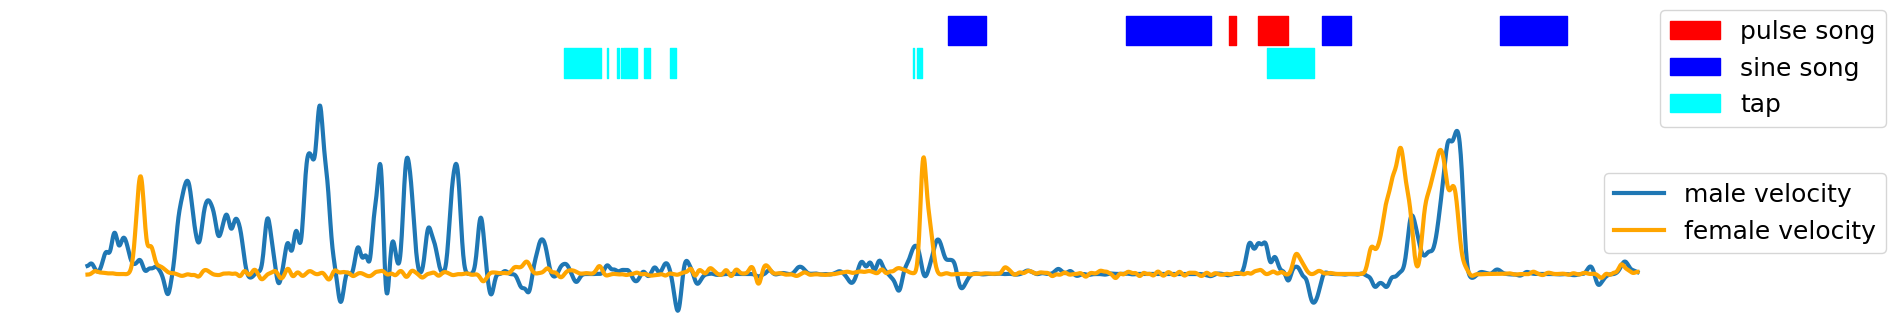

In [799]:
s = list(sessions_features.keys())[np.random.choice(len(sessions_features))]
s = '190724_121218_wt_18159206_rig1.2.h5'
# s = '190719_085355_wt_18159203_rig3.1.h5'

i = 0 #np.random.choice(len(sessions_features[s]['fFV']) - 3001)
r_ = np.r_[i:i+3000]
print(s, i)



fig = plt.figure(figsize=(22, 4))

gs = gridspec.GridSpec(2, 1, height_ratios=[3, 10], hspace=0.1)  # first ax is twice as tall as second
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.broken_barh(get_intervals(sessions_features[s]['pulse'][r_]), (1.6, 1), color='red', label='pulse song')
ax1.broken_barh(get_intervals(sessions_features[s]['sine'][r_]), (1.6, 1), color='blue', label='sine song')
ax1.broken_barh(get_intervals(sessions_features[s]['tap2'][r_]), (0.5, 1), color='cyan', label='tap')
ax1.legend(loc='upper right', fontsize='medium', bbox_to_anchor=(1.1, 1.05), borderaxespad=0.)
ax1.axis('off')

ax2.plot(smooth_gaussian(sessions_features[s]['mFV'][r_], 5), c='tab:blue', lw=3, label='male velocity')
ax2.plot(smooth_gaussian(sessions_features[s]['fFV'][r_], 5), c='orange', lw=3, label='female velocity')
# ax2.plot(sessions_features[s]['wingFlick'][r_]*0.1 - 0.3, c='orange', lw=3, label='wingFlick')
ax2.axis('off')
ax2.legend(loc='lower right', fontsize='medium', 
           bbox_to_anchor=(1.1, 0.3), 
           borderaxespad=0.
          )

plt.tight_layout()
plt.savefig(f'{figpath}/mfexample.pdf', transparent=True, dpi=300, bbox_inches='tight')
plt.show()